Pre trained weights and trained model is uploaded on google drive

In [ ]:
!git clone https://github.com/va1shn9v/PromptIR.git
# Move contents specifically to ensure 'net' and other folders are in the root
!cp -r PromptIR/* .
!rm -rf PromptIR
# Verify folders exist now
import os
print("Current directory folders:", [d for d in os.listdir('.') if os.path.isdir(d)])

Cloning into 'PromptIR'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 126 (delta 45), reused 37 (delta 37), pack-reused 70 (from 1)
Receiving objects: 100% (126/126), 1.39 MiB | 4.64 MiB/s, done.
Resolving deltas: 100% (53/53), done.
Current directory folders: ['.config', 'data', 'ckpt', 'net', 'utils', 'custom_dataset', 'raw_data', 'data_dir', 'sample_data']


In [ ]:
from net.model import PromptIR
model = PromptIR()
print("Listing first 20 parameter names to find the prompt layers:")
for i, (name, _) in enumerate(model.named_parameters()):
    print(name)
    if i > 50: break

Listing first 20 parameter names to find the prompt layers:
patch_embed.proj.weight
chnl_reduce1.weight
chnl_reduce2.weight
chnl_reduce3.weight
reduce_noise_channel_1.weight
encoder_level1.0.norm1.body.weight
encoder_level1.0.norm1.body.bias
encoder_level1.0.attn.temperature
encoder_level1.0.attn.qkv.weight
encoder_level1.0.attn.qkv_dwconv.weight
encoder_level1.0.attn.project_out.weight
encoder_level1.0.norm2.body.weight
encoder_level1.0.norm2.body.bias
encoder_level1.0.ffn.project_in.weight
encoder_level1.0.ffn.dwconv.weight
encoder_level1.0.ffn.project_out.weight
encoder_level1.1.norm1.body.weight
encoder_level1.1.norm1.body.bias
encoder_level1.1.attn.temperature
encoder_level1.1.attn.qkv.weight
encoder_level1.1.attn.qkv_dwconv.weight
encoder_level1.1.attn.project_out.weight
encoder_level1.1.norm2.body.weight
encoder_level1.1.norm2.body.bias
encoder_level1.1.ffn.project_in.weight
encoder_level1.1.ffn.dwconv.weight
encoder_level1.1.ffn.project_out.weight
encoder_level1.2.norm1.body.we

In [ ]:
# Inspect the PromptIR class definition to see default arguments
with open('net/model.py', 'r') as f:
    lines = f.readlines()
    for i, line in enumerate(lines):
        if 'class PromptIR' in line:
            print("".join(lines[i:i+15]))
            break

class PromptIR(nn.Module):
    def __init__(self, 
        inp_channels=3, 
        out_channels=3, 
        dim = 48,
        num_blocks = [4,6,6,8], 
        num_refinement_blocks = 4,
        heads = [1,2,4,8],
        ffn_expansion_factor = 2.66,
        bias = False,
        LayerNorm_type = 'WithBias',   ## Other option 'BiasFree'
        decoder = False,
    ):

        super(PromptIR, self).__init__()



In [ ]:
import cv2
import numpy as np
import os
import random
import urllib.request
import zipfile

# ==========================================
# 1. DOWNLOADING & SETUP
# ==========================================
def download_div2k(data_dir="raw_data"):
    """Downloads and extracts the DIV2K Validation dataset."""
    url = "http://data.vision.ee.ethz.ch/cvl/DIV2K/DIV2K_valid_HR.zip"
    zip_path = os.path.join(data_dir, "DIV2K_valid_HR.zip")
    extract_path = os.path.join(data_dir, "DIV2K_valid_HR")

    os.makedirs(data_dir, exist_ok=True)

    if not os.path.exists(extract_path):
        print("Downloading DIV2K Validation Dataset (approx. 700MB)...")
        urllib.request.urlretrieve(url, zip_path)
        print("Extracting files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        os.remove(zip_path)
        print("Download complete.")
    else:
        print("DIV2K dataset already exists locally.")

    return extract_path

# ==========================================
# 2. DEGRADATION FUNCTIONS
# ==========================================
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape).astype(np.float32)
    noisy_img = cv2.add(image.astype(np.float32), noise)
    return np.clip(noisy_img, 0, 255).astype(np.uint8)

def add_synthetic_rain(image):
    h, w, _ = image.shape
    rain_drops = np.zeros((h, w), dtype=np.uint8)
    num_drops = random.randint(300, 600)
    for _ in range(num_drops):
        x, y = random.randint(0, w-1), random.randint(0, h-1)
        rain_drops[y, x] = 255

    kernel = np.array([[0, 0, 1], [0, 1, 0], [1, 0, 0]], dtype=np.uint8)
    rain_streaks = cv2.filter2D(rain_drops, -1, kernel)
    rain_streaks = cv2.blur(rain_streaks, (3, 3))

    rain_streaks_colored = cv2.cvtColor(rain_streaks, cv2.COLOR_GRAY2BGR)
    return cv2.addWeighted(image, 0.8, rain_streaks_colored, 0.3, 0)

def add_dust_haze(image, intensity=0.6):
    dust_color = np.full_like(image, (130, 180, 210), dtype=np.uint8)
    hazed_img = cv2.addWeighted(image, 1 - intensity, dust_color, intensity, 0)
    return cv2.GaussianBlur(hazed_img, (7, 7), 0)

# ==========================================
# 3. PATCH EXTRACTION & PIPELINE
# ==========================================
def extract_random_patch(image, patch_size=512):
    """Extracts a random square patch from a high-res image."""
    h, w, _ = image.shape
    if h <= patch_size or w <= patch_size:
        return cv2.resize(image, (patch_size, patch_size))

    y = random.randint(0, h - patch_size)
    x = random.randint(0, w - patch_size)
    return image[y:y+patch_size, x:x+patch_size]

def build_fine_tuning_dataset(input_dir, output_dir="custom_dataset"):
    splits = ['train', 'test']
    categories = ['clean', 'noisy', 'rainy', 'dusty']

    for split in splits:
        for cat in categories:
            os.makedirs(os.path.join(output_dir, split, cat), exist_ok=True)

    images = [f for f in os.listdir(input_dir) if f.endswith(('.png', '.jpg'))]
    random.shuffle(images)

    total_clean_patches = 0
    print("Generating 200 Clean Patches and Synthesizing Degradations...")

    for i, filename in enumerate(images):
        if total_clean_patches >= 200: break
        img_path = os.path.join(input_dir, filename)
        img = cv2.imread(img_path)
        if img is None: continue

        for patch_idx in range(2):
            if total_clean_patches >= 200: break
            patch = extract_random_patch(img)
            split_name = 'train' if total_clean_patches < 160 else 'test'
            base_name = f"patch_{i}_{patch_idx}.png"

            cv2.imwrite(os.path.join(output_dir, split_name, 'clean', base_name), patch)
            cv2.imwrite(os.path.join(output_dir, split_name, 'noisy', base_name), add_gaussian_noise(patch))
            cv2.imwrite(os.path.join(output_dir, split_name, 'rainy', base_name), add_synthetic_rain(patch))
            cv2.imwrite(os.path.join(output_dir, split_name, 'dusty', base_name), add_dust_haze(patch))
            total_clean_patches += 1

    print(f"Success! Engineered {total_clean_patches} pairs. Saved in '{output_dir}'.")

if __name__ == "__main__":
    raw_path = download_div2k()
    build_fine_tuning_dataset(input_dir=raw_path)

Extracting files...
Download complete.
Generating 200 Clean Patches and Synthesizing Degradations...
Success! Engineered 200 pairs. Saved in 'custom_dataset'.


In [ ]:
import os
import sys
import torch
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Ensure local 'net' package is found
sys.path.append(os.getcwd())
from net.model import PromptIR

def evaluate_zero_shot_baseline():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Starting ZERO-SHOT BASELINE Evaluation on: {device}...")

    # 1. Initialize and load the ORIGINAL pretrained weights
    model = PromptIR(decoder=True).to(device)

    # IMPORTANT: Ensure this file is the original author's weights, NOT your custom ones
    weights_path = 'pretrained_weights.pth'
    if not os.path.exists(weights_path):
        print(f"Error: Could not find {weights_path}. Please download the original paper's weights to this directory.")
        return

    model.load_state_dict(torch.load(weights_path))
    model.eval()

    # 2. Setup transforms and directories
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])

    test_clean_dir = 'custom_dataset/test/clean'
    degradation_types = ['noisy', 'rainy', 'dusty']

    # 3. Print table header
    print("\n" + "="*85)
    print(" " * 25 + "ZERO-SHOT BASELINE METRICS (PRETRAINED WEIGHTS)")
    print("="*85)
    print(f"{'Degradation':<15} | {'Degraded PSNR':<15} | {'Zero-Shot PSNR':<15} | {'Zero-Shot SSIM':<15}")
    print("-" * 85)

    # 4. Evaluation Loop
    for deg in degradation_types:
        deg_dir = f'custom_dataset/test/{deg}'

        if not os.path.exists(deg_dir) or not os.path.exists(test_clean_dir):
            print(f"Skipping {deg}: Test directories not found.")
            continue

        images = [f for f in os.listdir(test_clean_dir) if f.endswith(('.png', '.jpg'))]

        deg_psnr_list = []
        restored_psnr_list = []
        restored_ssim_list = []

        for img_name in images:
            # Load clean and degraded images as standard NumPy arrays for metrics
            clean_path = os.path.join(test_clean_dir, img_name)
            deg_path = os.path.join(deg_dir, img_name)

            clean_np = cv2.resize(cv2.imread(clean_path), (128, 128))
            deg_np = cv2.resize(cv2.imread(deg_path), (128, 128))

            # Prepare PIL image for the PyTorch model
            deg_pil = Image.open(deg_path).convert('RGB')
            input_tensor = transform(deg_pil).unsqueeze(0).to(device)

            # Inference
            with torch.no_grad():
                restored_tensor = model(input_tensor)

            # Convert restored tensor back to a standard NumPy uint8 image
            restored_np = restored_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
            restored_np = np.clip(restored_np * 255.0, 0, 255).astype(np.uint8)
            restored_np = cv2.cvtColor(restored_np, cv2.COLOR_RGB2BGR)

            # Calculate metrics
            d_psnr = psnr_metric(clean_np, deg_np)
            r_psnr = psnr_metric(clean_np, restored_np)
            r_ssim = ssim_metric(clean_np, restored_np, channel_axis=2, data_range=255)

            deg_psnr_list.append(d_psnr)
            restored_psnr_list.append(r_psnr)
            restored_ssim_list.append(r_ssim)

        # Print the averaged results for this specific degradation
        avg_deg_psnr = np.mean(deg_psnr_list)
        avg_res_psnr = np.mean(restored_psnr_list)
        avg_res_ssim = np.mean(restored_ssim_list)

        print(f"{deg.capitalize():<15} | {avg_deg_psnr:<15.2f} | {avg_res_psnr:<15.2f} | {avg_res_ssim:<15.4f}")

    print("=" * 85 + "\n")

if __name__ == "__main__":
    evaluate_zero_shot_baseline()

Starting ZERO-SHOT BASELINE Evaluation on: cuda...

                         ZERO-SHOT BASELINE METRICS (PRETRAINED WEIGHTS)
Degradation     | Degraded PSNR   | Zero-Shot PSNR  | Zero-Shot SSIM 
-------------------------------------------------------------------------------------
Noisy           | 26.48           | 21.36           | 0.7534         
Rainy           | 20.18           | 21.51           | 0.7874         
Dusty           | 13.87           | 19.52           | 0.6271         



In [ ]:
import os
import sys
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

# Adding current directory to path to ensure local 'net' package is found
sys.path.append(os.getcwd())

# Import the model from the restored directory
from net.model import PromptIR

# ==========================================
# 1. CUSTOM DATALOADER
# ==========================================
class SyntheticDegradationDataset(Dataset):
    """Loads paired clean and degraded images from the custom Layer 1 dataset."""
    def __init__(self, dataset_dir="custom_dataset", split="train"):
        self.clean_dir = os.path.join(dataset_dir, split, "clean")
        self.degraded_dirs = [
            os.path.join(dataset_dir, split, "noisy"),
            os.path.join(dataset_dir, split, "rainy"),
            os.path.join(dataset_dir, split, "dusty")
        ]
        self.image_names = os.listdir(self.clean_dir)
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((128, 128)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_names) * 3

    def __getitem__(self, idx):
        clean_idx = idx // 3
        deg_type_idx = idx % 3
        img_name = self.image_names[clean_idx]

        clean_path = os.path.join(self.clean_dir, img_name)
        deg_path = os.path.join(self.degraded_dirs[deg_type_idx], img_name)

        clean_img = cv2.cvtColor(cv2.imread(clean_path), cv2.COLOR_BGR2RGB)
        deg_img = cv2.cvtColor(cv2.imread(deg_path), cv2.COLOR_BGR2RGB)

        return self.transform(deg_img), self.transform(clean_img)

# ==========================================
# 2. MODEL FREEZING LOGIC
# ==========================================
def setup_model_for_finetuning(model):
    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze layers related to the decoder and prompts based on naming convention
    for name, param in model.named_parameters():
        if any(key in name.lower() for key in ["dec_level", "up", "reduce", "prompt"]):
            param.requires_grad = True

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total Trainable Parameters: {trainable_params:,}")
    return model

# ==========================================
# 3. THE TRAINING LOOP
# ==========================================
def train_model():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Executing on: {device}")

    train_dataset = SyntheticDegradationDataset(split="train")
    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)

    # decoder=True is critical to align channels in the skip connections
    model = PromptIR(decoder=True)

    # Load weights if available
    if os.path.exists("pretrained_weights.pth"):
        model.load_state_dict(torch.load("pretrained_weights.pth"), strict=False)

    model = setup_model_for_finetuning(model).to(device)
    criterion = nn.L1Loss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=1e-4)

    epochs = 3
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for degraded_imgs, clean_imgs in train_loader:
            degraded_imgs, clean_imgs = degraded_imgs.to(device), clean_imgs.to(device)

            optimizer.zero_grad()
            outputs = model(degraded_imgs)
            loss = criterion(outputs, clean_imgs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}] - Average L1 Loss: {running_loss/len(train_loader):.4f}")

    torch.save(model.state_dict(), "custom_promptir_weights.pth")
    print("Training complete. Weights saved to custom_promptir_weights.pth.")

if __name__ == "__main__":
    train_model()

Executing on: cuda
Total Trainable Parameters: 5,478,959
Epoch [1/3] - Average L1 Loss: 0.1016
Epoch [2/3] - Average L1 Loss: 0.0752
Epoch [3/3] - Average L1 Loss: 0.0666
Training complete. Weights saved to custom_promptir_weights.pth.


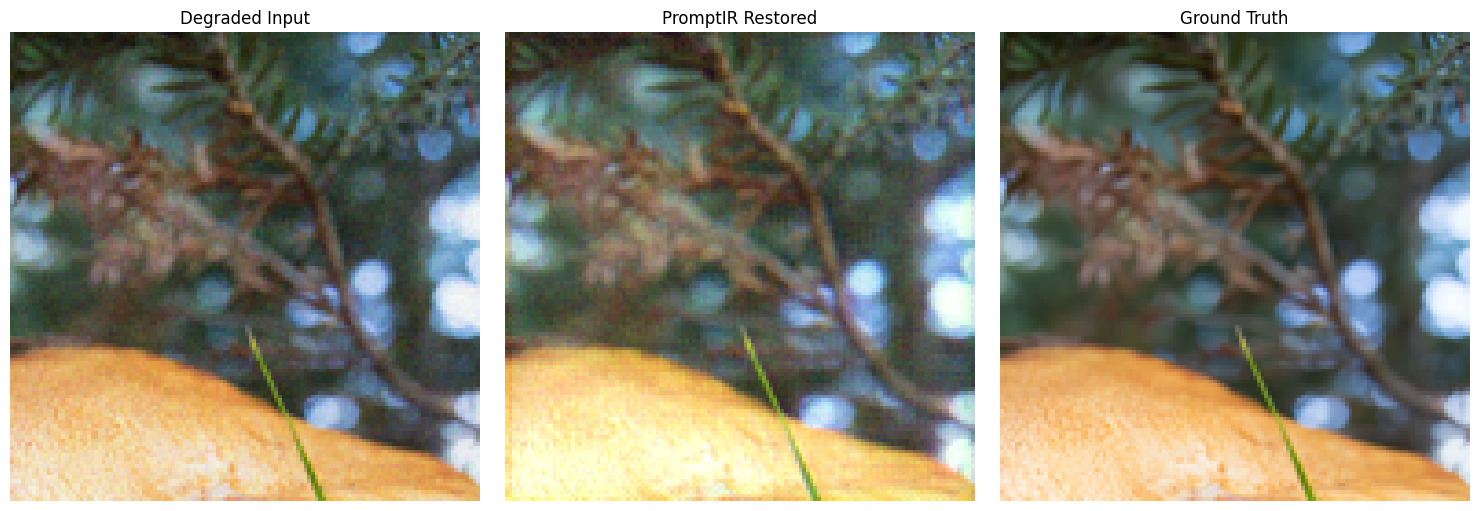

In [ ]:
import torch
import matplotlib.pyplot as plt
from net.model import PromptIR
from PIL import Image
import torchvision.transforms as transforms
import os
import random

def test_inference():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = PromptIR(decoder=True).to(device)
    model.load_state_dict(torch.load('custom_promptir_weights.pth'))
    model.eval()

    # Pick a random degraded image from the test set
    test_clean_dir = 'custom_dataset/test/clean'
    test_noisy_dir = 'custom_dataset/test/noisy'
    img_name = random.choice(os.listdir(test_clean_dir))

    clean_img = Image.open(os.path.join(test_clean_dir, img_name)).convert('RGB')
    degraded_img = Image.open(os.path.join(test_noisy_dir, img_name)).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])

    input_tensor = transform(degraded_img).unsqueeze(0).to(device)

    with torch.no_grad():
        restored_tensor = model(input_tensor)

    # Plotting
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(degraded_img.resize((128, 128)))
    plt.title('Degraded Input')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(restored_tensor.squeeze().cpu().permute(1, 2, 0).clamp(0, 1))
    plt.title('PromptIR Restored')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(clean_img.resize((128, 128)))
    plt.title('Ground Truth')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

test_inference()

In [ ]:
import os
import sys
import torch
import cv2
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric

# Ensure local 'net' package is found
sys.path.append(os.getcwd())
from net.model import PromptIR

def evaluate_test_set():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Starting Evaluation on: {device}...")

    # 1. Initialize and load your fine-tuned weights
    model = PromptIR(decoder=True).to(device)

    weights_path = 'custom_promptir_weights.pth'
    if not os.path.exists(weights_path):
        print(f"Error: Could not find {weights_path}. Did you run the training script?")
        return

    model.load_state_dict(torch.load(weights_path))
    model.eval()

    # 2. Setup transforms and directories
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor()
    ])

    test_clean_dir = 'custom_dataset/test/clean'
    degradation_types = ['noisy', 'rainy', 'dusty']

    # 3. Print table header
    print("\n" + "="*75)
    print(f"{'Degradation':<15} | {'Degraded PSNR':<15} | {'Restored PSNR':<15} | {'Restored SSIM':<15}")
    print("-" * 75)

    # 4. Evaluation Loop
    for deg in degradation_types:
        deg_dir = f'custom_dataset/test/{deg}'

        if not os.path.exists(deg_dir) or not os.path.exists(test_clean_dir):
            print(f"Skipping {deg}: Test directories not found.")
            continue

        images = [f for f in os.listdir(test_clean_dir) if f.endswith(('.png', '.jpg'))]

        deg_psnr_list = []
        restored_psnr_list = []
        restored_ssim_list = []

        for img_name in images:
            # Load clean and degraded images as standard NumPy arrays for metrics
            clean_path = os.path.join(test_clean_dir, img_name)
            deg_path = os.path.join(deg_dir, img_name)

            clean_np = cv2.resize(cv2.imread(clean_path), (128, 128))
            deg_np = cv2.resize(cv2.imread(deg_path), (128, 128))

            # Prepare PIL image for the PyTorch model
            deg_pil = Image.open(deg_path).convert('RGB')
            input_tensor = transform(deg_pil).unsqueeze(0).to(device)

            # Inference
            with torch.no_grad():
                restored_tensor = model(input_tensor)

            # Convert restored tensor back to a standard NumPy uint8 image
            restored_np = restored_tensor.squeeze().cpu().permute(1, 2, 0).numpy()
            restored_np = np.clip(restored_np * 255.0, 0, 255).astype(np.uint8)
            restored_np = cv2.cvtColor(restored_np, cv2.COLOR_RGB2BGR)

            # Calculate metrics
            # PSNR: Higher is better (less noise)
            # SSIM: Closer to 1.0 is better (structural match)
            d_psnr = psnr_metric(clean_np, deg_np)
            r_psnr = psnr_metric(clean_np, restored_np)

            # win_size must be odd and smaller than the image dimensions.
            # channel_axis=2 explicitly tells it we are using color images (H, W, C)
            r_ssim = ssim_metric(clean_np, restored_np, channel_axis=2, data_range=255)

            deg_psnr_list.append(d_psnr)
            restored_psnr_list.append(r_psnr)
            restored_ssim_list.append(r_ssim)

        # Print the averaged results for this specific degradation
        avg_deg_psnr = np.mean(deg_psnr_list)
        avg_res_psnr = np.mean(restored_psnr_list)
        avg_res_ssim = np.mean(restored_ssim_list)

        print(f"{deg.capitalize():<15} | {avg_deg_psnr:<15.2f} | {avg_res_psnr:<15.2f} | {avg_res_ssim:<15.4f}")

    print("=" * 75 + "\n")

if __name__ == "__main__":
    evaluate_test_set()

Starting Evaluation on: cuda...

Degradation     | Degraded PSNR   | Restored PSNR   | Restored SSIM  
---------------------------------------------------------------------------
Noisy           | 26.48           | 21.36           | 0.7534         
Rainy           | 20.18           | 21.51           | 0.7874         
Dusty           | 13.87           | 19.52           | 0.6271         



In [ ]:
# How many keys are in your saved checkpoint?
ckpt = torch.load('custom_promptir_weights.pth')
print(f"Keys in saved checkpoint: {len(ckpt)}")

# How many parameters does the full model have?
from net.model import PromptIR
model = PromptIR(decoder=True)
full_state = model.state_dict()
print(f"Keys in full model: {len(full_state)}")

Keys in saved checkpoint: 548
Keys in full model: 548
